<a href="https://colab.research.google.com/github/Adishree194/spotify-analysis/blob/main/SpotifyAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas numpy seaborn matplotlib plotly

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/SpotifyFeatures.csv")

In [4]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0.0,0.611,0.389,99373.0,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1.0,0.246,0.590,137373.0,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3.0,0.952,0.663,170267.0,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0.0,0.703,0.240,152427.0,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4.0,0.950,0.331,82625.0,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224030 entries, 0 to 224029
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             224030 non-null  object 
 1   artist_name       224030 non-null  object 
 2   track_name        224029 non-null  object 
 3   track_id          224030 non-null  object 
 4   popularity        224029 non-null  float64
 5   acousticness      224029 non-null  float64
 6   danceability      224029 non-null  float64
 7   duration_ms       224029 non-null  float64
 8   energy            224029 non-null  float64
 9   instrumentalness  224029 non-null  float64
 10  key               224029 non-null  object 
 11  liveness          224029 non-null  float64
 12  loudness          224029 non-null  float64
 13  mode              224029 non-null  object 
 14  speechiness       224029 non-null  float64
 15  tempo             224029 non-null  float64
 16  time_signature    22

In [6]:
df.describe()


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,224029.000000,224029.000000,224029.000000,2.240290e+05,224029.000000,224029.000000,224029.000000,224029.000000,224029.000000,224029.000000,224029.000000
mean,40.837842,0.370682,0.552868,2.351035e+05,0.570864,0.151687,0.216346,-9.613104,0.122588,117.675429,0.453631
std,18.397716,0.356911,0.186989,1.204213e+05,0.265552,0.306063,0.199857,6.072989,0.188239,30.965188,0.260689
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,28.000000,0.037000,0.433000,1.823600e+05,0.382000,0.000000,0.097500,-11.867000,0.036800,92.882000,0.235000
50%,43.000000,0.233000,0.569000,2.202270e+05,0.607000,0.000044,0.129000,-7.754000,0.050300,115.875000,0.443000
75%,54.000000,0.731000,0.691000,2.658460e+05,0.789000,0.040500,0.266000,-5.481000,0.107000,139.200000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.dropna(inplace=True)

In [9]:
top_songs = df.sort_values(by='popularity', ascending=False).head(10)
print(top_songs[['track_name', 'artist_name', 'popularity']])

                                      track_name    artist_name  popularity
9027                                     7 rings  Ariana Grande       100.0
107804                                   7 rings  Ariana Grande       100.0
107802  break up with your girlfriend, i'm bored  Ariana Grande        99.0
107803                                      Wow.    Post Malone        99.0
86951                                       Wow.    Post Malone        99.0
9026    break up with your girlfriend, i'm bored  Ariana Grande        99.0
138918                                 Con Calma   Daddy Yankee        98.0
107909                                 Con Calma   Daddy Yankee        98.0
66643                                  Con Calma   Daddy Yankee        98.0
107829                          Sweet but Psycho        Ava Max        97.0


In [10]:
least_popular = df[df['popularity'] == 0]
print(f"Number of songs with 0 popularity: {len(least_popular)}")

Number of songs with 0 popularity: 6291


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
numeric_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms',
                'energy', 'instrumentalness', 'liveness', 'loudness',
                'speechiness', 'tempo', 'valence']
correlation = df[numeric_cols].corr()

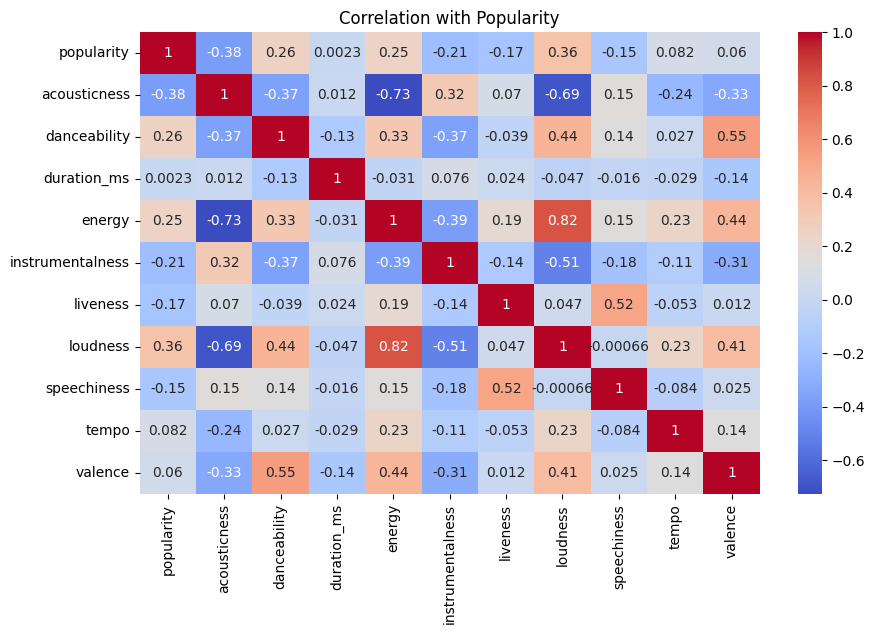

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation with Popularity')
plt.show()

<Axes: title={'center': 'Top 10 Genres by Popularity'}, ylabel='genre'>

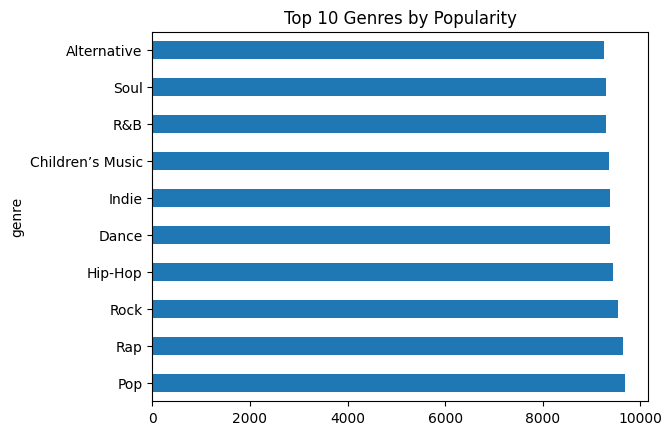

In [13]:
top_genres = df['genre'].value_counts().head(10)
top_genres.plot(kind='barh', title='Top 10 Most Frequent Genres')

# Top genres by average popularity
top_popular_genres = df.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(10)
top_popular_genres.plot(kind='barh', title='Top 10 Genres by Popularity')

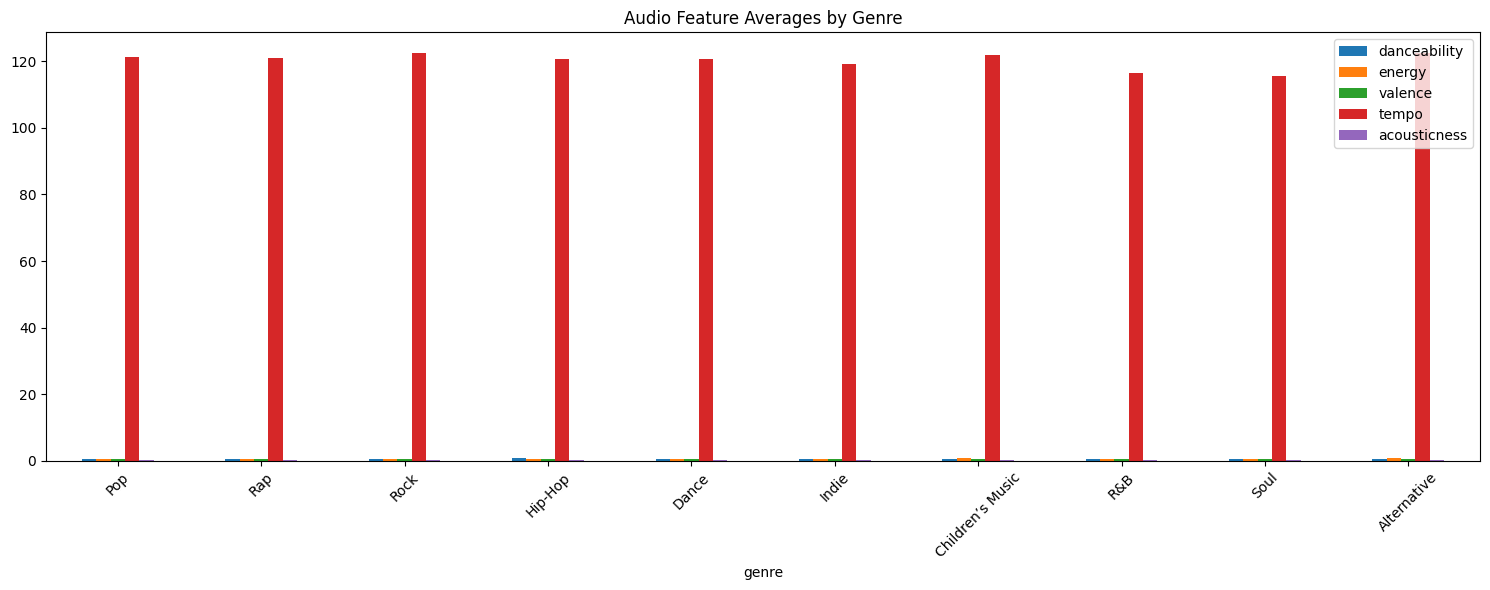

In [14]:
feature_cols = ['danceability', 'energy', 'valence', 'tempo', 'acousticness']
genre_features = df.groupby('genre')[feature_cols].mean().loc[top_popular_genres.index]

genre_features.plot(kind='bar', figsize=(15, 6))
plt.title('Audio Feature Averages by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

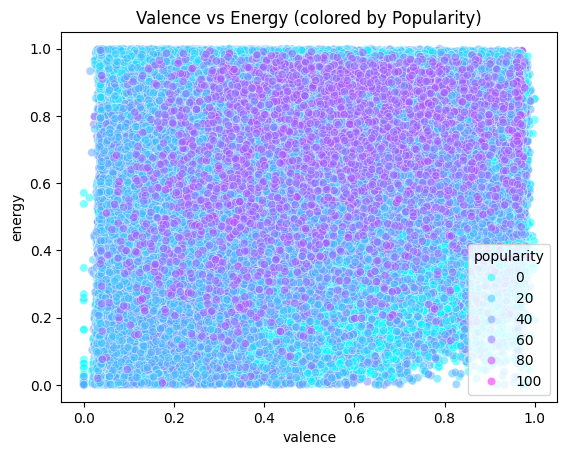

In [15]:
sns.scatterplot(data=df, x='valence', y='energy', hue='popularity', palette='cool', alpha=0.5)
plt.title("Valence vs Energy (colored by Popularity)")
plt.show()